Cool scripts to have fun with 

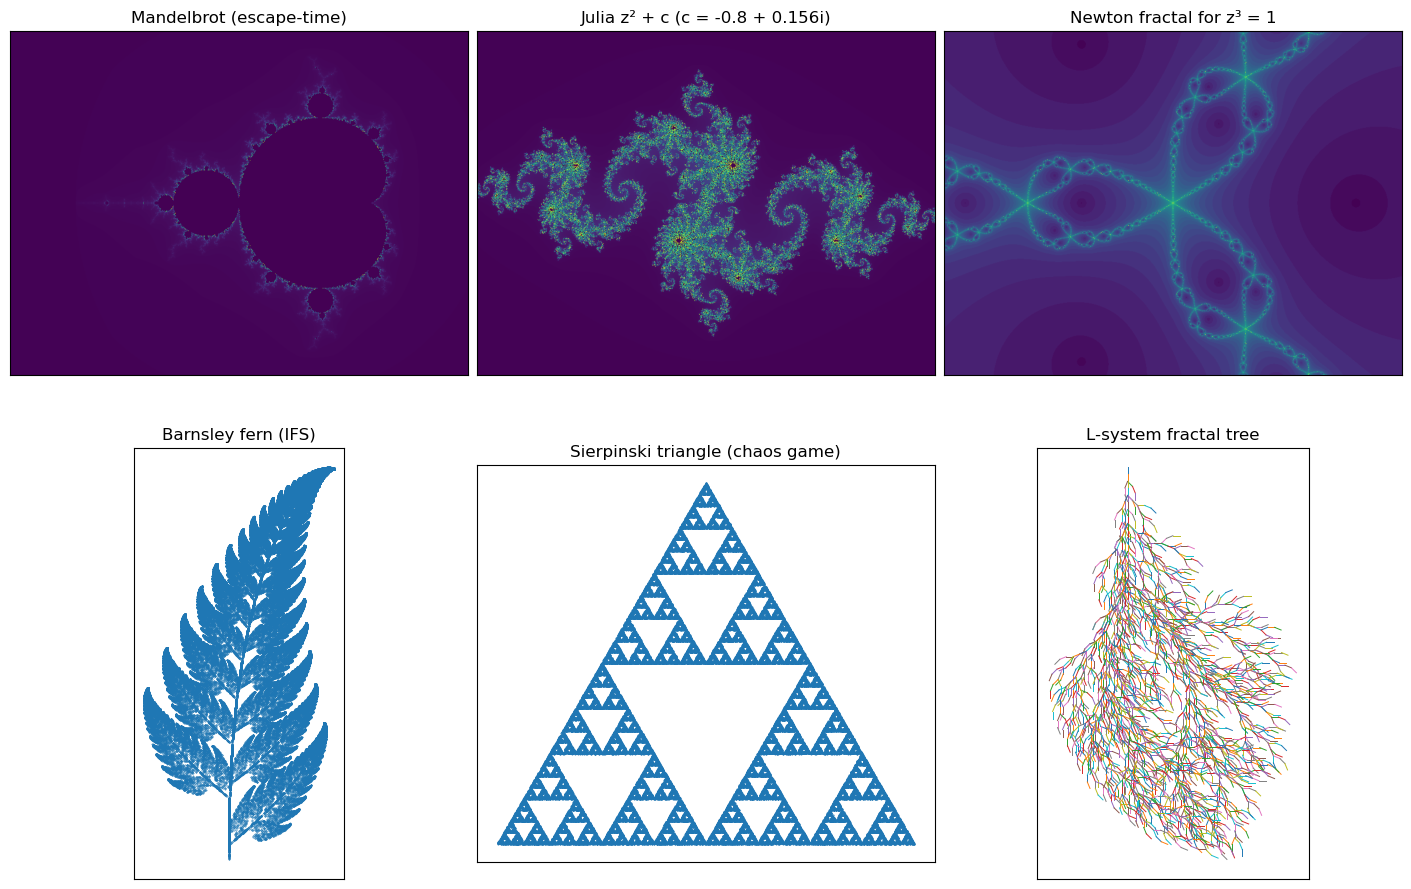

In [3]:
# Fractals in Jupyter — Gallery + Interactive Explorer
# ----------------------------------------------------
# Requirements: numpy, matplotlib. (Optional: numba, ipywidgets)
# Tip: In JupyterLab, you can use either of the below magics:
# %matplotlib inline      # static rendering (safe default)
# %matplotlib widget      # interactive figure (if available)

import math
import numpy as np
import matplotlib.pyplot as plt

# Optional acceleration with numba
try:
    from numba import njit
except Exception:
    def njit(*args, **kwargs):
        # no-op decorator if numba isn't available
        def inner(f): return f
        return inner

# -------------------------
# 1) Escape-time fractals
# -------------------------

@njit(fastmath=True)
def _mandelbrot_panel(xmin, xmax, ymin, ymax, width, height, max_iter):
    """Return a 2D array of 'smooth' escape times for the Mandelbrot set."""
    img = np.zeros((height, width), np.float32)
    for j in range(height):
        cy = ymin + (ymax - ymin) * j / (height - 1)
        for i in range(width):
            cx = xmin + (xmax - xmin) * i / (width - 1)
            c_re = cx
            c_im = cy
            z_re = 0.0
            z_im = 0.0
            n = 0
            # Iterate z <- z^2 + c
            while (z_re*z_re + z_im*z_im) <= 4.0 and n < max_iter:
                # (a+bi)^2 = (a^2 - b^2) + 2abi
                zr2 = z_re*z_re - z_im*z_im + c_re
                zi2 = 2.0*z_re*z_im + c_im
                z_re, z_im = zr2, zi2
                n += 1
            if n < max_iter:
                # Smooth escape time
                mod2 = z_re*z_re + z_im*z_im
                # mu = n + 1 - log2(log|z|)
                mu = n + 1.0 - math.log(math.log(math.sqrt(mod2), math.e), 2.0)
                img[j, i] = mu
            else:
                img[j, i] = 0.0
    # Normalize to [0,1]
    m = img.max()
    if m > 0:
        img /= m
    return img


@njit(fastmath=True)
def _julia_panel(xmin, xmax, ymin, ymax, width, height, max_iter, c_re, c_im):
    """Return a 2D array of 'smooth' escape times for a Julia set z^2 + c."""
    img = np.zeros((height, width), np.float32)
    for j in range(height):
        zy = ymin + (ymax - ymin) * j / (height - 1)
        for i in range(width):
            zx = xmin + (xmax - xmin) * i / (width - 1)
            z_re = zx
            z_im = zy
            n = 0
            while (z_re*z_re + z_im*z_im) <= 4.0 and n < max_iter:
                # z <- z^2 + c
                zr2 = z_re*z_re - z_im*z_im + c_re
                zi2 = 2.0*z_re*z_im + c_im
                z_re, z_im = zr2, zi2
                n += 1
            if n < max_iter:
                mod2 = z_re*z_re + z_im*z_im
                mu = n + 1.0 - math.log(math.log(math.sqrt(mod2), math.e), 2.0)
                img[j, i] = mu
            else:
                img[j, i] = 0.0
    m = img.max()
    if m > 0:
        img /= m
    return img


def mandelbrot(center=(-0.75, 0.0), zoom=1.0, width=800, height=600, max_iter=300):
    """Convenience wrapper around _mandelbrot_panel with 'sane' aspect and zoom."""
    # We keep the canonical aspect ~3.5:2.0, centered at 'center', then apply zoom.
    aspect = width / height
    span_x = 3.5 / zoom
    span_y = span_x / aspect
    cx, cy = center
    xmin, xmax = cx - span_x/2, cx + span_x/2
    ymin, ymax = cy - span_y/2, cy + span_y/2
    return _mandelbrot_panel(xmin, xmax, ymin, ymax, width, height, max_iter), (xmin, xmax, ymin, ymax)


def julia(c=(-0.8, 0.156), center=(0.0, 0.0), zoom=1.0, width=800, height=600, max_iter=300):
    """Convenience wrapper around _julia_panel."""
    aspect = width / height
    span_x = 3.5 / zoom
    span_y = span_x / aspect
    cx, cy = center
    xmin, xmax = cx - span_x/2, cx + span_x/2
    ymin, ymax = cy - span_y/2, cy + span_y/2
    img = _julia_panel(xmin, xmax, ymin, ymax, width, height, max_iter, c[0], c[1])
    return img, (xmin, xmax, ymin, ymax)


# -------------------------
# 2) Newton fractal (z^3=1)
# -------------------------

@njit(fastmath=True)
def _newton_z3_panel(xmin, xmax, ymin, ymax, width, height, max_iter=50, tol=1e-6):
    """
    Newton fractal for f(z)=z^3-1, using z <- z - f/df.
    Returns a float image encoding both root index (0,1,2) and iterations.
    """
    img = np.zeros((height, width), np.float32)
    # The three cube roots of 1:
    r0 = 1.0 + 0.0j
    r1 = -0.5 + (math.sqrt(3)/2.0)*1j
    r2 = -0.5 - (math.sqrt(3)/2.0)*1j

    for j in range(height):
        y = ymin + (ymax - ymin) * j / (height - 1)
        for i in range(width):
            x = xmin + (xmax - xmin) * i / (width - 1)
            z_re, z_im = x, y
            it = 0
            # Iterate Newton
            while it < max_iter:
                # f(z) = z^3 - 1
                # df = 3 z^2
                # Complex mults by hand
                zr, zi = z_re, z_im
                # z^2
                z2_re = zr*zr - zi*zi
                z2_im = 2.0*zr*zi
                # z^3 = z^2 * z
                z3_re = z2_re*zr - z2_im*zi
                z3_im = z2_re*zi + z2_im*zr
                # f = z^3 - 1
                f_re = z3_re - 1.0
                f_im = z3_im
                # |f|
                if (f_re*f_re + f_im*f_im) < tol*tol:
                    break
                # df = 3 z^2
                df_re = 3.0*z2_re
                df_im = 3.0*z2_im
                # f/df
                denom = df_re*df_re + df_im*df_im
                if denom == 0.0:
                    break
                q_re = (f_re*df_re + f_im*df_im)/denom
                q_im = (f_im*df_re - f_re*df_im)/denom
                # z <- z - f/df
                z_re -= q_re
                z_im -= q_im
                it += 1
            # Choose nearest root
            z = complex(z_re, z_im)
            d0 = abs(z - r0)
            d1 = abs(z - r1)
            d2 = abs(z - r2)
            root_index = 0
            dmin = d0
            if d1 < dmin:
                dmin = d1
                root_index = 1
            if d2 < dmin:
                root_index = 2
            # Encode: iterations + small root offset (to separate basins visually)
            img[j, i] = it + (root_index / 4.0)
    # Normalize
    m = img.max()
    if m > 0:
        img /= m
    return img


def newton_z3(center=(0.0, 0.0), span=2.5, width=800, height=600, max_iter=50):
    aspect = width / height
    xmin = center[0] - span/2
    xmax = center[0] + span/2
    ymin = center[1] - (span/aspect)/2
    ymax = center[1] + (span/aspect)/2
    img = _newton_z3_panel(xmin, xmax, ymin, ymax, width, height, max_iter=max_iter)
    return img, (xmin, xmax, ymin, ymax)


# -------------------------
# 3) IFS & Chaos game
# -------------------------

def barnsley_fern(n_points=120_000, skip=100, seed=0):
    """Iterated Function System for Barnsley fern. Returns x,y arrays."""
    rng = np.random.default_rng(seed)
    x = np.empty(n_points, np.float32)
    y = np.empty(n_points, np.float32)
    # Start at origin
    xi, yi = 0.0, 0.0
    k = 0
    while k < n_points + skip:
        r = rng.random()
        if r < 0.01:
            xn = 0.0
            yn = 0.16*yi
        elif r < 0.86:
            xn = 0.85*xi + 0.04*yi
            yn = -0.04*xi + 0.85*yi + 1.6
        elif r < 0.93:
            xn = 0.20*xi - 0.26*yi
            yn = 0.23*xi + 0.22*yi + 1.6
        else:
            xn = -0.15*xi + 0.28*yi
            yn = 0.26*xi + 0.24*yi + 0.44
        xi, yi = xn, yn
        if k >= skip:
            x[k - skip] = xi
            y[k - skip] = yi
        k += 1
    return x, y


def sierpinski_triangle(n_points=50_000, seed=0):
    """Chaos game for Sierpinski triangle. Returns x,y arrays."""
    rng = np.random.default_rng(seed)
    # Equilateral triangle vertices
    v = np.array([[0.0, 0.0],
                  [1.0, 0.0],
                  [0.5, math.sqrt(3)/2.0]], dtype=np.float32)
    p = np.array([0.2, 0.3])  # start
    pts = np.empty((n_points, 2), np.float32)
    for i in range(n_points):
        j = rng.integers(0, 3)
        p = 0.5*(p + v[j])
        pts[i] = p
    return pts[:, 0], pts[:, 1]


# -------------------------
# 4) L-system (fractal tree)
# -------------------------

def lsystem_expand(axiom, rules, iterations):
    s = axiom
    for _ in range(iterations):
        s = "".join(rules.get(ch, ch) for ch in s)
    return s


def lsystem_turtle(path, step=1.0, angle_deg=25.0):
    """
    Turtle interpreter for strings with:
      'F' forward, '+' turn left, '-' turn right, '[' push, ']' pop.
    Returns two arrays (x_segments, y_segments) where each is a (N,2) array of segment endpoints.
    """
    angle = math.radians(angle_deg)
    x, y, th = 0.0, 0.0, -math.pi/2  # start pointing up
    stack = []
    segs_x = []
    segs_y = []
    for ch in path:
        if ch == 'F':
            x2 = x + step*math.cos(th)
            y2 = y + step*math.sin(th)
            segs_x.append((x, x2))
            segs_y.append((y, y2))
            x, y = x2, y2
        elif ch == '+':
            th += angle
        elif ch == '-':
            th -= angle
        elif ch == '[':
            stack.append((x, y, th))
        elif ch == ']':
            x, y, th = stack.pop()
    return np.array(segs_x, dtype=np.float32), np.array(segs_y, dtype=np.float32)


# -------------------------
# 5) Gallery rendering
# -------------------------

def draw_gallery():
    """Render a 2x3 grid of fractals with sensible defaults."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

    # Mandelbrot
    m_img, m_ext = mandelbrot(center=(-0.75, 0.0), zoom=1.0, width=800, height=600, max_iter=400)
    ax = axes[0, 0]
    ax.imshow(m_img, extent=(m_ext[0], m_ext[1], m_ext[2], m_ext[3]), origin='lower')
    ax.set_title("Mandelbrot (escape-time)")
    ax.set_xticks([]); ax.set_yticks([])

    # Julia
    j_img, j_ext = julia(c=(-0.8, 0.156), center=(0.0, 0.0), zoom=1.2, width=800, height=600, max_iter=400)
    ax = axes[0, 1]
    ax.imshow(j_img, extent=(j_ext[0], j_ext[1], j_ext[2], j_ext[3]), origin='lower')
    ax.set_title("Julia z² + c (c = -0.8 + 0.156i)")
    ax.set_xticks([]); ax.set_yticks([])

    # Newton (z^3 = 1)
    n_img, n_ext = newton_z3(center=(0.0, 0.0), span=2.5, width=800, height=600, max_iter=40)
    ax = axes[0, 2]
    ax.imshow(n_img, extent=(n_ext[0], n_ext[1], n_ext[2], n_ext[3]), origin='lower')
    ax.set_title("Newton fractal for z³ = 1")
    ax.set_xticks([]); ax.set_yticks([])

    # Barnsley fern
    x, y = barnsley_fern(n_points=120_000, seed=1)
    ax = axes[1, 0]
    ax.scatter(x, y, s=0.1)
    ax.set_title("Barnsley fern (IFS)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

    # Sierpinski triangle
    xs, ys = sierpinski_triangle(n_points=60_000, seed=2)
    ax = axes[1, 1]
    ax.scatter(xs, ys, s=0.2)
    ax.set_title("Sierpinski triangle (chaos game)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

    # L-system tree
    axiom = "F"
    rules = {"F": "FF+[+F-F-F]-[-F+F+F]"}
    path = lsystem_expand(axiom, rules, iterations=4)
    sx, sy = lsystem_turtle(path, step=1.0, angle_deg=22.5)
    ax = axes[1, 2]
    for (x0, x1), (y0, y1) in zip(sx, sy):
        ax.plot([x0, x1], [y0, y1], linewidth=0.7)
    ax.set_title("L-system fractal tree")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

    plt.show()


# -------------------------
# 6) Interactive Mandelbrot (optional)
# -------------------------

def interactive_mandelbrot():
    """
    Interactive zoom & pan for the Mandelbrot set using ipywidgets (if available).
    Graceful text fallback if ipywidgets is not installed.
    """
    try:
        import ipywidgets as W
        from IPython.display import display, clear_output

        width, height = 800, 600
        center_x = W.FloatSlider(value=-0.75, min=-2.0, max=0.5, step=0.001, description='Center X')
        center_y = W.FloatSlider(value=0.0,  min=-1.25, max=1.25, step=0.001, description='Center Y')
        zoom     = W.FloatLogSlider(value=1.0, base=2, min=0, max=16, step=0.1, description='Zoom (×)')
        iters    = W.IntSlider(value=400, min=50, max=2000, step=50, description='Max iter')

        out = W.Output()

        def redraw(*_):
            with out:
                clear_output(wait=True)
                img, ext = mandelbrot(center=(center_x.value, center_y.value),
                                      zoom=zoom.value, width=width, height=height,
                                      max_iter=iters.value)
                fig, ax = plt.subplots(figsize=(7, 5))
                ax.imshow(img, extent=(ext[0], ext[1], ext[2], ext[3]), origin='lower')
                ax.set_xticks([]); ax.set_yticks([])
                ax.set_title(f"Mandelbrot @ center=({center_x.value:.4f},{center_y.value:.4f}), zoom×{zoom.value:.2f}, iters={iters.value}")
                plt.show()

        for w in (center_x, center_y, zoom, iters):
            w.observe(redraw, names='value')

        ui = W.VBox([W.HBox([center_x, center_y]), W.HBox([zoom, iters])])
        display(ui, out)
        redraw()

    except Exception as e:
        print("Interactive mode requires `ipywidgets`. To try it:")
        print("  pip install ipywidgets")
        print("  jupyter nbextension enable --py widgetsnbextension   # classic notebook")
        print("  # JupyterLab 3+: ipywidgets works out of the box once installed.")
        print("\nFalling back to a static Mandelbrot render...")
        img, ext = mandelbrot()
        plt.figure(figsize=(7,5))
        plt.imshow(img, extent=(ext[0], ext[1], ext[2], ext[3]), origin='lower')
        plt.xticks([]); plt.yticks([])
        plt.title("Mandelbrot (static fallback)")
        plt.show()


# -------------------------
# 7) Run: gallery + explorer
# -------------------------

if __name__ == "__main__" or True:
    draw_gallery()
